# Session 3: Audio Lab with Torchaudio
This notebook guides you through audio preprocessing, augmentation, and visualization using **Torchaudio**, and compares it to **Librosa**.

## 🔍 Objectives
By the end of this lab, you will be able to:
- Load and inspect audio files using Torchaudio
- Convert stereo to mono and resample audio
- Visualize waveforms and spectrograms
- Perform data augmentation using Torchaudio transforms and sox_effects
- Compare audio features (MFCC, MelSpectrogram) between Torchaudio and Librosa
- Prepare audio datasets for machine learning models

##  Part 1: Load and Inspect Audio
**Task**
Load an audio file using `torchaudio.load()` and inspect its waveform shape, sample rate, and duration. Convert to mono if stereo.

To convert to mono, you should average both signal

In [2]:

from google.colab import files
import torchaudio
import matplotlib.pyplot as plt
import IPython.display as ipd
import torch.nn.functional as F
import torchaudio.transforms as T
import torch




In [4]:
uploaded = files.upload()


Saving train.wav to train.wav


In [5]:
filename=list(uploaded.keys())[0]

In [6]:
waveform, sr = torchaudio.load(filename)
# Print waveform shape
print("Waveform shape:", waveform.shape)
# Print sample rate
print("Sample rate:", sr)

# Compute duration in seconds
num_channels, num_samples = waveform.shape
duration = num_samples / sr

print("Duration (seconds):", duration)
ipd.Audio(waveform.numpy(), rate=sr)

Waveform shape: torch.Size([2, 276858])
Sample rate: 44100
Duration (seconds): 6.277959183673469


In [7]:
# If audio file is stereo convert to mono
if waveform.shape[0] > 1:
    waveform = waveform.mean(dim=0, keepdim=True)

print("Waveform shape:", waveform.shape)

Waveform shape: torch.Size([1, 276858])


## Part 2: Resample and Pad/Trim Audio
### **Task**
Resample audio to 16000 Hz and pad or trim to exactly 6 seconds, listen the new audio

In [8]:

import torch.nn.functional as F

target_sr = 16000
target_duration=6

target_len = target_sr * target_duration

print(f"Original sample rate: {sr} Hz")
print(f" Original length: {waveform.shape[1]} samples ({duration:.2f} seconds)")
print(f" Target length: {target_len} samples ({target_duration} seconds at {target_sr} Hz)")

#Resampling
resample = T.Resample(orig_freq=sr, new_freq=target_sr)
waveform_resampled = resample(waveform)
print(" Resampled to", target_sr)
print(f" Resampled length: {waveform_resampled.shape[1]} samples ({waveform.shape[1]/sr:.2f} seconds)")

print('### NOW LET TRIM OR PAD')
# Pad or Trim ---
'''
Do pad if the audio is shorter than the target length
Do trim if the audio is longer than the target length

'''
num_samples = waveform_resampled.shape[1]
if num_samples < target_len:
    pad_amount = target_len - num_samples
    waveform_final = F.pad(waveform_resampled, (0, pad_amount))  # Right-pad only
    print(f" Padded: new shape = {waveform_final.shape}")
elif num_samples > target_len:
    waveform_final = waveform_resampled[:, :target_len]
    print(f" Trimmed: new shape = {waveform_final.shape}")
else:
    print(" Already the correct length:", waveform_final.shape)

Original sample rate: 44100 Hz
 Original length: 276858 samples (6.28 seconds)
 Target length: 96000 samples (6 seconds at 16000 Hz)
 Resampled to 16000
 Resampled length: 100448 samples (6.28 seconds)
### NOW LET TRIM OR PAD
 Trimmed: new shape = torch.Size([1, 96000])


In [9]:
ipd.Audio(waveform_final.numpy(), rate=target_sr)

## Part 3: Plot Waveform with Time Axis
###  **Task**
Create a function to plot the spectrogram obtained from TorchAudio. Add an option to plot or not in db scale

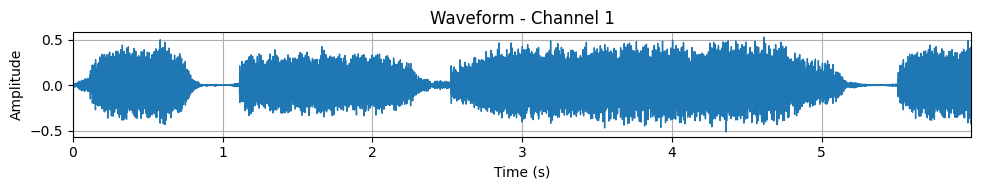

In [10]:
def plot_waveform(waveform, sr, title="Waveform", ax=None):
    waveform = waveform.numpy()

    num_channels, num_frames = waveform.shape
    time_axis = torch.arange(0, num_frames) / sr
    time_axis = time_axis.numpy()

    if ax is None:
        fig, ax = plt.subplots(num_channels, 1, figsize=(10, 2 * num_channels))
        if num_channels == 1:
            ax = [ax]

    for i in range(num_channels):
        ax[i].plot(time_axis, waveform[i], linewidth=1)
        ax[i].set_xlabel("Time (s)")
        ax[i].set_ylabel("Amplitude")
        ax[i].set_xlim([0, time_axis[-1]])
        ax[i].grid(True)
        ax[i].set_title(f"{title} - Channel {i+1}")

    plt.tight_layout()
    plt.show()

plot_waveform(waveform_final, target_sr)


##  Part 4: Feature Extraction (MFCC & MelSpectrogram)
### **Task**
Compute and compare MFCC and MelSpectrogram using both Torchaudio and Librosa. For this create a function

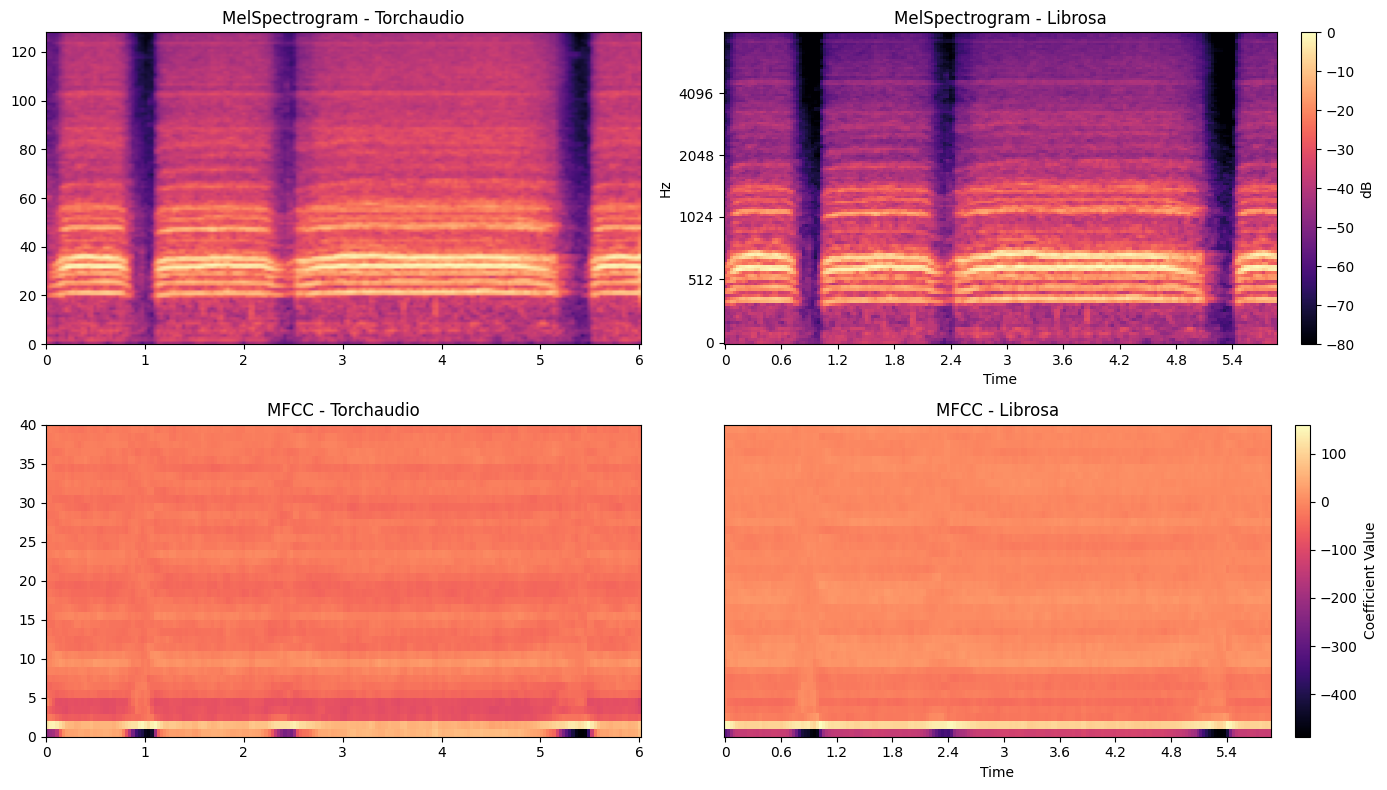

In [62]:
import librosa.display
import numpy as np

n_fft = 2048
hop_length = 512
n_mels = 128
n_mfcc = 40


mel_torch = T.MelSpectrogram(
    sample_rate=target_sr,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=n_mels,
    window_fn=torch.hann_window
)(waveform_final)
mel_torch_db = torchaudio.functional.amplitude_to_DB(mel_torch, multiplier=10.0, amin=1e-10, db_multiplier=0.0)


mfcc_torch = T.MFCC(
    sample_rate=target_sr,
    n_mfcc=n_mfcc,
    melkwargs={
        "n_fft": n_fft,
        "hop_length": hop_length,
        "n_mels": n_mels,
        "window_fn": torch.hann_window
    }
)(waveform_final)

waveform_np = waveform_final.numpy().squeeze()
mel_librosa = librosa.feature.melspectrogram(
    y=waveform_np,
    sr=target_sr,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=n_mels,
    window='hann',
    center=False
)

mfcc_librosa = librosa.feature.mfcc(
    y=waveform_np,
    sr=target_sr,
    n_mfcc=n_mfcc,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=n_mels,
    window='hann',
    center=False

)

#To have xaxis in seconds
num_frames = mel_torch_np = mel_torch_db[0].detach().numpy().shape[1]

time_torch = np.linspace(0, num_frames * hop_length / target_sr, num_frames)
extent_mel = [time_torch[0], time_torch[-1], 0, n_mels]
extent_mfcc = [time_torch[0], time_torch[-1], 0, n_mfcc]


fig, ax = plt.subplots(2, 2, figsize=(14, 8))

ax[0][0].imshow(mel_torch_db[0].detach().numpy(), aspect='auto', origin='lower', cmap='magma', extent=extent_mel)
ax[0][0].set_title("MelSpectrogram - Torchaudio")

img1=librosa.display.specshow(librosa.power_to_db(mel_librosa, ref=np.max),
                         sr=target_sr, hop_length=hop_length,
                         x_axis='time', y_axis='mel', ax=ax[0][1])
ax[0][1].set_title("MelSpectrogram - Librosa")
cbar0 = fig.colorbar(img1, ax=ax[0][1], orientation='vertical', fraction=0.03, pad=0.04)
cbar0.set_label("dB")
ax[1][0].imshow(mfcc_torch[0].detach().numpy(), aspect='auto', origin='lower', cmap='magma', extent=extent_mfcc)
ax[1][0].set_title("MFCC - Torchaudio")

img2=librosa.display.specshow(mfcc_librosa,
                         sr=target_sr, hop_length=hop_length,
                         x_axis='time', ax=ax[1][1], cmap='magma')
ax[1][1].set_title("MFCC - Librosa")
cbar1 = fig.colorbar(img2, ax=ax[1][1], orientation='vertical', fraction=0.04, pad=0.04)
cbar1.set_label("Coefficient Value")

plt.tight_layout()
plt.show()


## Part 5: Data Augmentation with Sox Effects
### **Task**
Apply effects like lowpass, speed change, and reverb using `sox_effects`, and look at the difference in the MelSpect. Listen the different sounds. Comments

In [ ]:
!apt-get install -y sox libsox-dev libsox-fmt-all


In [ ]:
#if you want a list of all the effect :
torchaudio.sox_effects.effect_names()

In [26]:

# I select random effect that I want to test
effect_sets = [
    [["speed", "0.2"], ["rate", f"{target_sr}"]],
    [["pitch", "300"], ["rate", f"{target_sr}"]],
    [["reverb", "-w"]],
    [["reverb", "50", "50", "90"]],
    [["lowpass", "-1", "4000"]],
]
augmented_waveforms = []
augmented_sr = []

for effects in effect_sets:
    aug_wave, aug_sr = torchaudio.sox_effects.apply_effects_tensor(waveform_final, target_sr, effects)
    augmented_waveforms.append(aug_wave)
    augmented_sr.append(aug_sr)
    print(f"Effect: {effects}")
    display(ipd.Audio(aug_wave, rate=aug_sr))

Effect: [['speed', '0.2'], ['rate', '16000']]


Effect: [['pitch', '300'], ['rate', '16000']]


Effect: [['reverb', '-w']]


Effect: [['reverb', '50', '50', '90']]


Effect: [['lowpass', '-1', '4000']]


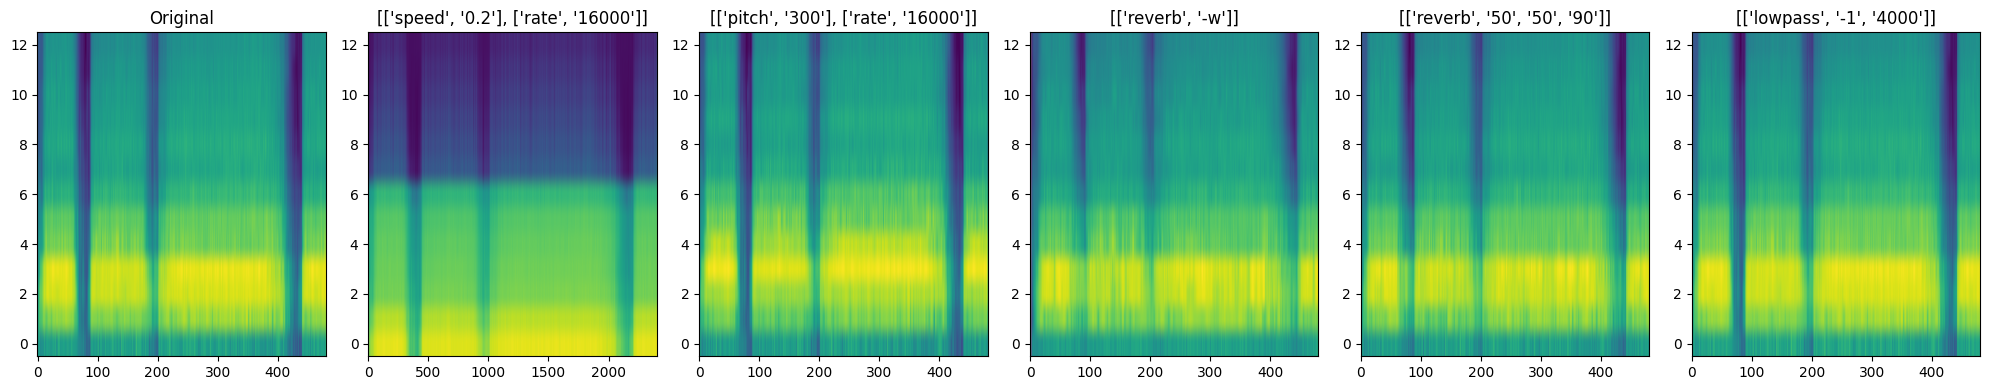

In [32]:
mel_spec_transform = T.MelSpectrogram(sample_rate=target_sr, n_mels=13)
original_mel = mel_spec_transform(waveform_final).squeeze().log2().numpy()
aug_mels = [mel_spec_transform(w[0]).log2().numpy() for w in augmented_waveforms]


# Plot original + augmented MelSpectrograms
fig, axes = plt.subplots(1, 6, figsize=(20, 4))
axes[0].imshow(original_mel, aspect='auto', origin='lower')
axes[0].set_title("Original")
for i, mel in enumerate(aug_mels):
    axes[i+1].imshow(mel, aspect='auto', origin='lower')
    axes[i+1].set_title(f"{effect_sets[i]}")
plt.tight_layout()

## Part 6: Frequency & Time Masking
### **Task**
Apply `TimeMasking` and `FrequencyMasking` to simulate missing data or noise.

Change the param and describe

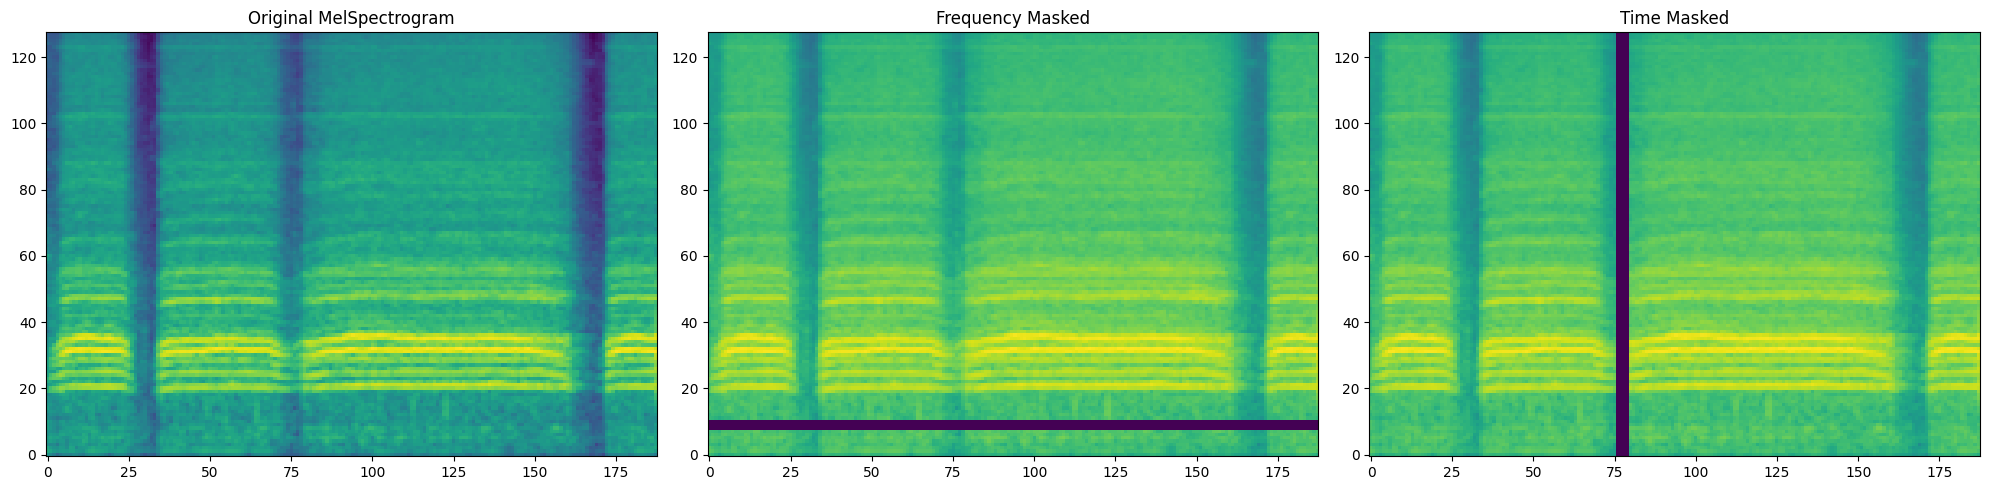

In [75]:

# Apply Frequency Masking
freq_mask = T.FrequencyMasking(freq_mask_param=10)
mel_freq_masked = freq_mask(mel_torch.clone())

# Apply Time Masking
time_mask = T.TimeMasking(time_mask_param=35)
mel_time_masked = time_mask(mel_torch.clone())


# Convert to dB for visualization
mel_torch_db = torchaudio.functional.amplitude_to_DB(mel_torch, multiplier=10.0, amin=1e-10, db_multiplier=0.0)
mel_freq_masked_db = torchaudio.functional.amplitude_to_DB(mel_freq_masked, multiplier=10.0, amin=1e-10, db_multiplier=0.0)
mel_time_masked_db = torchaudio.functional.amplitude_to_DB(mel_time_masked, multiplier=10.0, amin=1e-10, db_multiplier=0.0)

# Plot original and masked spectrograms
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
axs[0].imshow(mel_torch_db[0].detach().numpy(), origin='lower', aspect='auto')
axs[0].set_title("Original MelSpectrogram")
axs[1].imshow(mel_freq_masked_db[0].detach().numpy(), origin='lower', aspect='auto')
axs[1].set_title("Frequency Masked")
axs[2].imshow(mel_time_masked_db[0].detach().numpy(), origin='lower', aspect='auto')
axs[2].set_title("Time Masked")


plt.tight_layout()
plt.show()


## Part 7: Dataset & Pipeline
###**Task**
Wrap preprocessing and augmentation into a dataset-ready pipeline using `nn.Sequential`.

/usr/local/lib/python3.11/dist-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


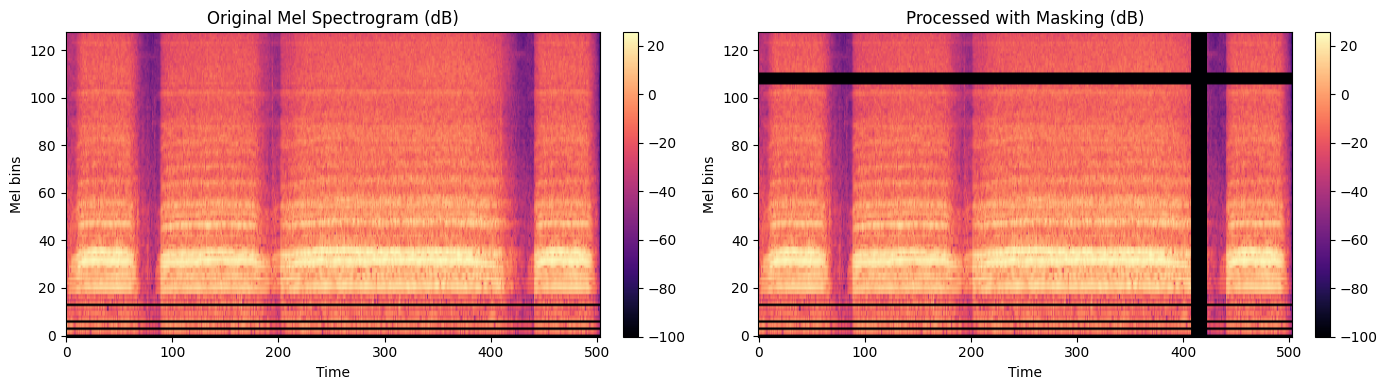

In [82]:

import torch.nn as nn
waveform, sr = torchaudio.load(filename)
resample = T.Resample(orig_freq=sr, new_freq=16000)
waveform_resampled = resample(waveform)

pipeline = nn.Sequential(
    T.Resample(orig_freq=sr, new_freq=16000),
    T.MelSpectrogram(sample_rate=16000),
    T.FrequencyMasking(freq_mask_param=10),
    T.TimeMasking(time_mask_param=20)
)

processed = pipeline(waveform)  # Shape: [1, n_mels, time]
processed_db = torchaudio.functional.amplitude_to_DB(processed, multiplier=10.0, amin=1e-10, db_multiplier=0.0)

original_mel = T.MelSpectrogram(sample_rate=target_sr)(waveform_resampled)
original_db = torchaudio.functional.amplitude_to_DB(original_mel, multiplier=10.0, amin=1e-10, db_multiplier=0.0)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# Original
img0 = ax[0].imshow(original_db[0].detach().numpy(), aspect='auto', origin='lower', cmap='magma')
ax[0].set_title("Original Mel Spectrogram (dB)")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Mel bins")
fig.colorbar(img0, ax=ax[0], fraction=0.03, pad=0.04)

# Processed
img1 = ax[1].imshow(processed_db[0].detach().numpy(), aspect='auto', origin='lower', cmap='magma')
ax[1].set_title("Processed with Masking (dB)")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Mel bins")
fig.colorbar(img1, ax=ax[1], fraction=0.03, pad=0.04)

plt.tight_layout()
plt.show()
